In [15]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import scipy
import seaborn as sns
import sklearn
import pysindy as ps 
from sklearn.linear_model import Lasso
from tools.tools import get_positive_contributions, compute_entropy, print_equations, compute_gram_matrix_for_sindy
from data_generators.data_func import plot_clustered_kuramoto, generate_kuramoto_cluster_data_sin_cos
import warnings
from sklearn.exceptions import ConvergenceWarning

# 仅忽略收敛警告
warnings.filterwarnings("ignore", category=ConvergenceWarning)


pipline操作流程：

1.生成数据：a 单起始点时间序列；b 多起始点时间序列

可选步骤：时间序列降采样

2.选择合适的library做观测

3.选择合适的optimizer做拟合：a 离散的迭代方程；b 连续的微分方程

4.计算score，多步预测效果看一下

5.提取系数矩阵，进行svd分解，得到奇异值谱和左奇异向量

6.观察奇异值谱截断，计算因果涌现程度，绘制多尺度contribution，计算EC

7.根据奇异向量和谱截断，输出粗粒化函数表达式

8.绘制宏观演化的时间序列，给出宏观动力学方程

可选的分析案例：

1.SIR：原始的SIR动力学；带观测噪音的四维微观数据

2.kuramoto模型

3.洛伦兹动力学

4.耦合Rulkov映射

# 数据生成

In [2]:
N=10
n_clusters=2  # 团数
K_intra=5
K_inter=0.11
noise=0
dt=0.01

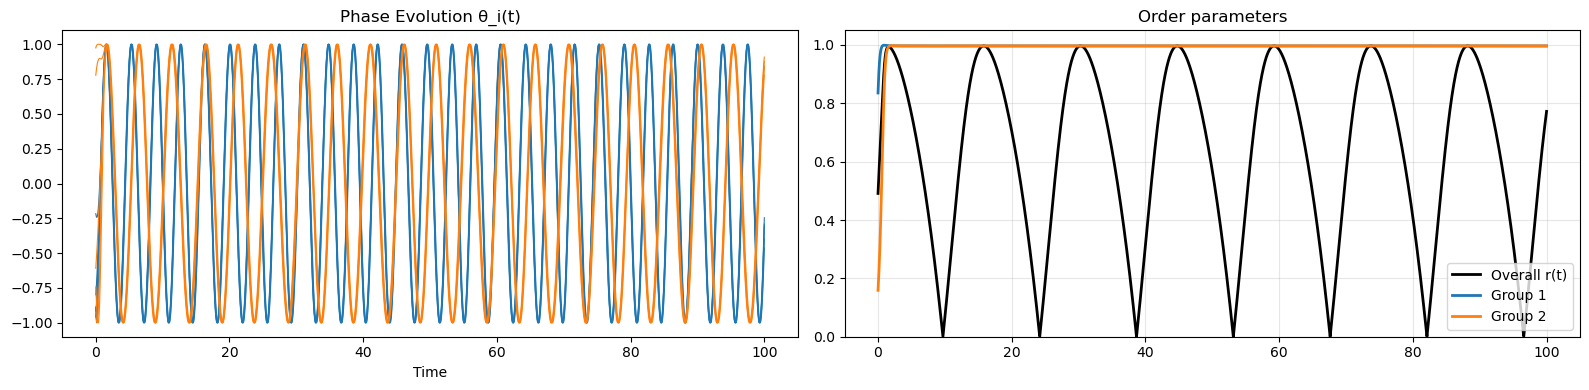

In [3]:
# 单时间序列采样
x_train, theta_hist, t_train, K_matrix = plot_clustered_kuramoto(
    N=N,          # 振子数
    n_clusters=n_clusters,  # 团数
    K_intra=K_intra,   # 团内耦合
    K_inter=K_inter,   # 团间耦合
    noise=noise,
    T=100,
    random_seed1=0, random_seed2=0,
    dt=dt
)

x_data = x_train[1000:,:]


# 选择library

In [16]:
# 候选的观测函数
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
ode_lib = ps.PolynomialLibrary(degree=2,include_bias=False)
library_functions = [
    lambda x: 1,
    lambda x: x,
    lambda x: np.sin(x),
    lambda x: np.cos(x),
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

# 选定观测函数
library = ide + fourier

# 进行lift
library.fit(x_data)
x_data_lift = library.transform(x_data)
names = library.get_feature_names()

# 单时间序列
print(x_data_lift.shape)
# 多时间序列
#print(x_data_lift[0].shape)
# 检查观测函数变量名
print(names)

(9000, 60)
['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'sin(1 x0)', 'cos(1 x0)', 'sin(1 x1)', 'cos(1 x1)', 'sin(1 x2)', 'cos(1 x2)', 'sin(1 x3)', 'cos(1 x3)', 'sin(1 x4)', 'cos(1 x4)', 'sin(1 x5)', 'cos(1 x5)', 'sin(1 x6)', 'cos(1 x6)', 'sin(1 x7)', 'cos(1 x7)', 'sin(1 x8)', 'cos(1 x8)', 'sin(1 x9)', 'cos(1 x9)', 'sin(1 x10)', 'cos(1 x10)', 'sin(1 x11)', 'cos(1 x11)', 'sin(1 x12)', 'cos(1 x12)', 'sin(1 x13)', 'cos(1 x13)', 'sin(1 x14)', 'cos(1 x14)', 'sin(1 x15)', 'cos(1 x15)', 'sin(1 x16)', 'cos(1 x16)', 'sin(1 x17)', 'cos(1 x17)', 'sin(1 x18)', 'cos(1 x18)', 'sin(1 x19)', 'cos(1 x19)']


检测到 1 条轨迹
各轨迹时间步数: [9000]
总样本数 M = 9000
观测函数个数 N = 60
使用均匀权重（所有样本等权重）
Gram 矩阵形状: (60, 60)
Gram矩阵形状: (60, 60)

矩阵是否对称: True
矩阵条件数: 8.5651e+16
最小特征值: -4.5687e-15


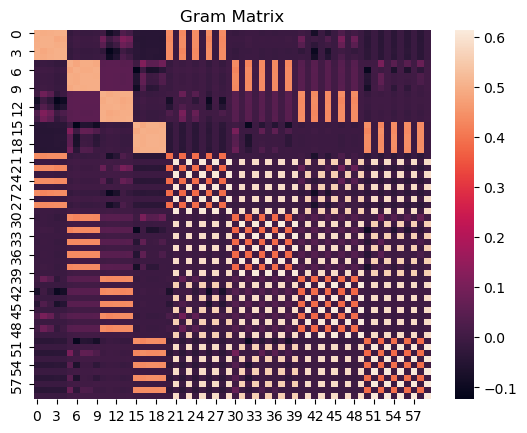

In [17]:
# 用真实轨迹分布估计 Gram，避免与动力学分布失配
# 如果后续有多轨迹，可传入 [traj1, traj2, ...] 并设置 weights="traj"
G = compute_gram_matrix_for_sindy(library, [x_data], weights="uniform")

print(f"Gram矩阵形状: {G.shape}")
print(f"\n矩阵是否对称: {np.allclose(G, G.T, atol=1e-10)}")
print(f"矩阵条件数: {np.linalg.cond(G):.4e}")
print(f"最小特征值: {np.min(np.linalg.eigvalsh((G + G.T) / 2)):.4e}")
sns.heatmap(G)
plt.title("Gram Matrix")
plt.show()


# 进行拟合

In [18]:
x_data_lift.shape

(9000, 60)

In [19]:
# 离散的迭代方程 or 连续的微分方程
discrete_time = False

# 候选拟合器
sr3_optimizer = ps.SR3(reg_weight_lam=0.2, regularizer="l2")
lasso_optimizer = Lasso(alpha=0.005, max_iter=20000, fit_intercept=False)
stlsq_optimizer = ps.STLSQ(threshold=0.01, alpha=0.9, verbose=True)

optimizer = lasso_optimizer

# 这里 x_data_lift 已经手动 lift，所以拟合阶段用 IdentityLibrary
model = ps.SINDy(feature_library=ide, optimizer=optimizer, discrete_time=discrete_time)
model.fit(x_data_lift, t=dt, feature_names=names)
model.print()


(x0)' = 0.005 x5 + 0.008 x6 + 0.003 x7 + -1.667 x10 + -0.001 x11 + -0.013 x12 + -0.017 x13
(x1)' = 0.017 x5 + -1.699 x11
(x2)' = 0.009 x5 + 0.007 x7 + -0.725 x10 + -0.980 x11
(x3)' = 0.016 x9 + -0.048 x10 + -1.651 x13
(x4)' = 0.010 x7 + 0.002 x8 + 0.004 x9 + -1.379 x10 + -0.320 x13
(x5)' = 0.018 x1 + -1.256 x15 + -0.002 x17
(x6)' = 0.019 x3 + -1.258 x16
(x7)' = 0.012 x0 + 0.001 x1 + 0.006 x2 + -0.726 x15 + -0.540 x16 + -0.001 x17
(x8)' = 0.013 x0 + 0.001 x1 + 0.005 x2 + -0.694 x15 + -0.572 x16 + -0.001 x17
(x9)' = 0.009 x0 + 0.009 x3 + 0.001 x4 + -0.356 x15 + -0.909 x16
(x10)' = 1.698 x0 + 0.010 x15 + 0.007 x16
(x11)' = 1.699 x1 + 0.017 x15
(x12)' = 0.724 x0 + 0.981 x1 + 0.010 x15 + 0.007 x17
(x13)' = 0.051 x0 + 1.648 x3 + 0.016 x19
(x14)' = 1.383 x0 + 0.316 x3 + 0.014 x17 + 0.001 x18 + 0.002 x19
(x15)' = 1.258 x5 + 0.003 x10 + 0.015 x11
(x16)' = 1.258 x6 + 0.019 x13
(x17)' = 0.726 x5 + 0.540 x6 + 0.001 x7 + 0.014 x10 + 0.004 x12
(x18)' = 0.695 x5 + 0.572 x6 + 0.001 x7 + 0.015 x10 + 0.

In [20]:
# 计算score
model.score(x_data_lift, t=dt)

0.9679013676419935

# 多步预测

In [21]:
test_idx = 0
init_data = x_data_lift[0, :]
step_pred = 2000

if discrete_time:
    X_data_predicted = model.simulate(init_data, step_pred)
else:
    # 连续系统必须传入真实时间轴，否则时间尺度会错误
    t_pred = np.arange(step_pred) * dt
    X_data_predicted = model.simulate(init_data, t_pred)

X_data_predicted.shape


(2000, 60)

/var/folders/mw/53dhwskj4zq47dtls4lhht4m0000gn/T/ipykernel_4285/2308130201.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


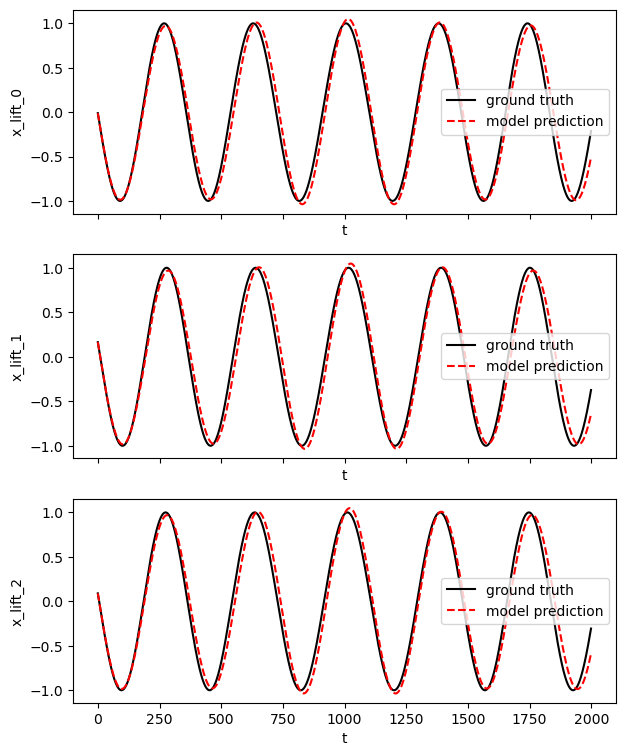

In [22]:
# 只看部分维度的多步预测
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(7, 9))
for i in range(3):
    axs[i].plot(x_data_lift[:step_pred, i], "k", label="ground truth")
    axs[i].plot(X_data_predicted[:step_pred, i], "r--", label="model prediction")
    axs[i].legend()
    axs[i].set(xlabel="t", ylabel=r"x_lift_{}".format(i))
fig.show()

# svd分解

orientation check: err(A)=5.843e+00, err(A.T)=0.000e+00
Gram eig min/max: -4.353e-15/1.171e+01


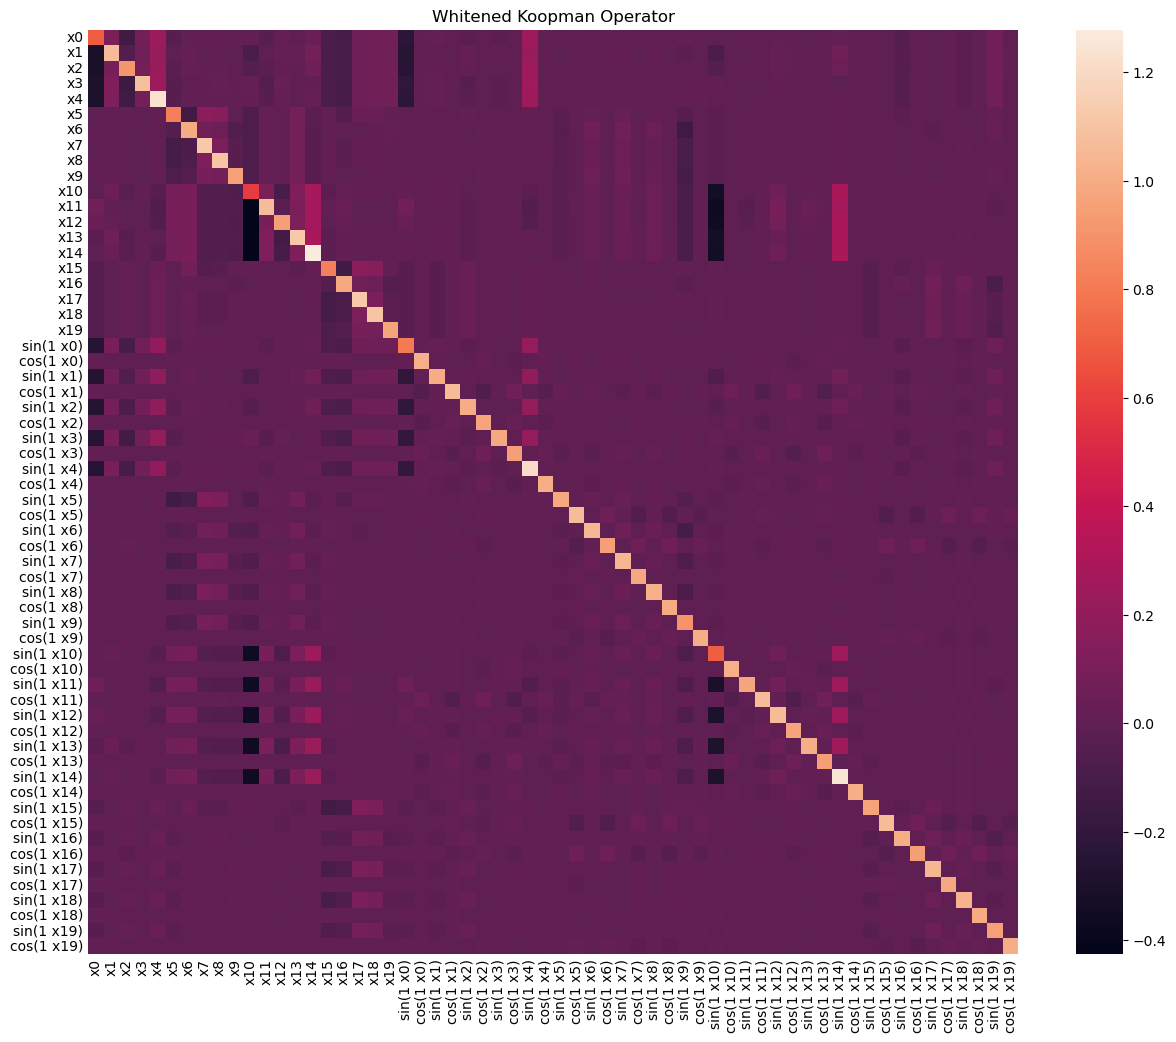

In [23]:
def inverse_sqrt_psd(M, eps=1e-10):
    """Stable inverse square root for symmetric PSD matrix."""
    M_sym = 0.5 * (M + M.T)
    evals, evecs = np.linalg.eigh(M_sym)
    evals_clipped = np.clip(evals, eps, None)
    M_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals_clipped)) @ evecs.T
    M_sqrt = evecs @ np.diag(np.sqrt(evals_clipped)) @ evecs.T
    return M_sqrt, M_inv_sqrt, evals

A_raw = model.coefficients()

# 系数方向一致性检查：选预测误差更小的方向
xdot_model = model.predict(x_data_lift)
err_no_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw.T) / np.linalg.norm(xdot_model)
err_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw) / np.linalg.norm(xdot_model)
A_ct = A_raw if err_t <= err_no_t else A_raw.T
print(f"orientation check: err(A)={err_t:.3e}, err(A.T)={err_no_t:.3e}")

# 连续系统转单步离散算子
A_step = scipy.linalg.expm(A_ct * dt) if not discrete_time else A_ct

G_sqrt, G_inv_sqrt, G_eigs = inverse_sqrt_psd(G, eps=1e-10)
A = G_sqrt @ A_step @ G_inv_sqrt

print(f"Gram eig min/max: {G_eigs.min():.3e}/{G_eigs.max():.3e}")

plt.figure(figsize=(15, 12))
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(A, xticklabels=names, yticklabels=names)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Whitened Koopman Operator")
plt.show()


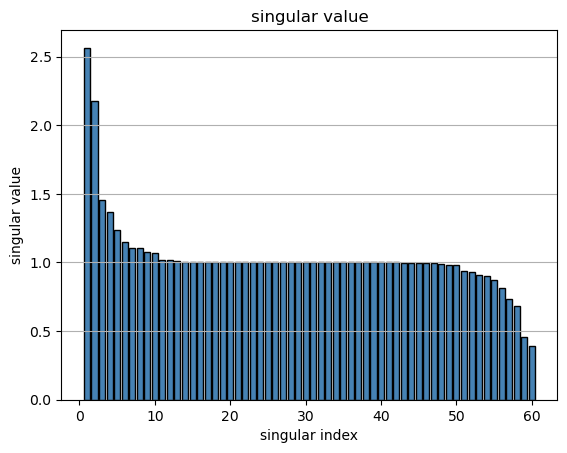

In [24]:
# SVD
U,S,V = np.linalg.svd(A)
plt.figure()
plt.bar(np.arange(1, len(S)+1), S, color='steelblue', edgecolor='k')
plt.grid(True, axis='y')         
plt.xlabel('singular index')
plt.ylabel('singular value')
plt.title('singular value')
plt.show()

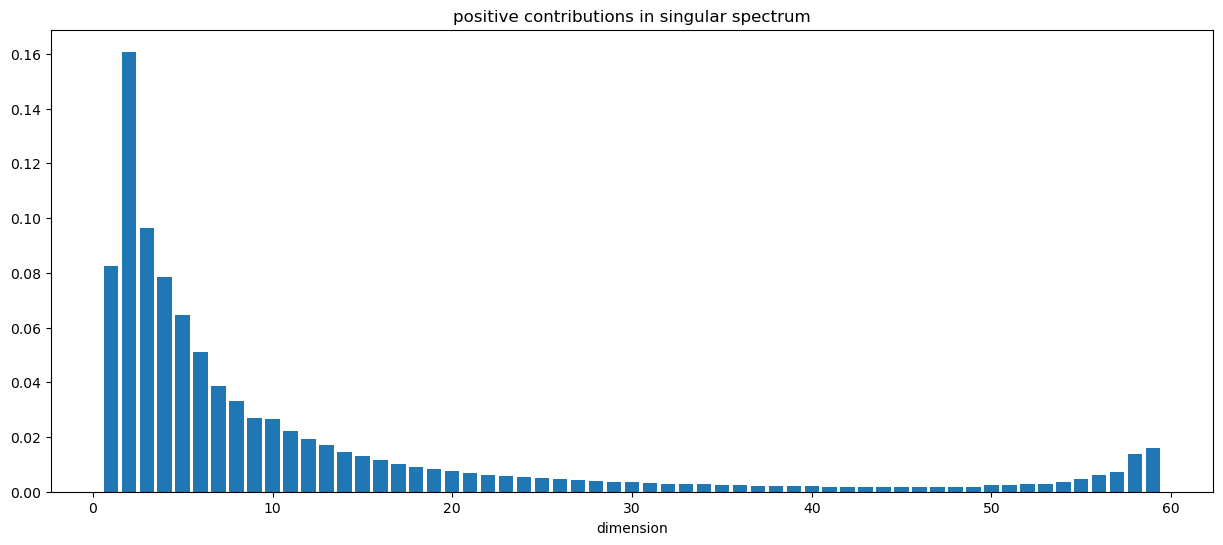

In [25]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(15, 6))
plt.bar(range(1,len(diff)+1), diff) 
plt.xlabel('dimension')
plt.title('positive contributions in singular spectrum')
plt.show()

In [26]:
# 选取截断
rank = 2
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(delt_gamma)

1.337945080903691


In [27]:
# 计算EC
print(compute_entropy(diff))

4.59032398545425


# 输出粗粒化表达式

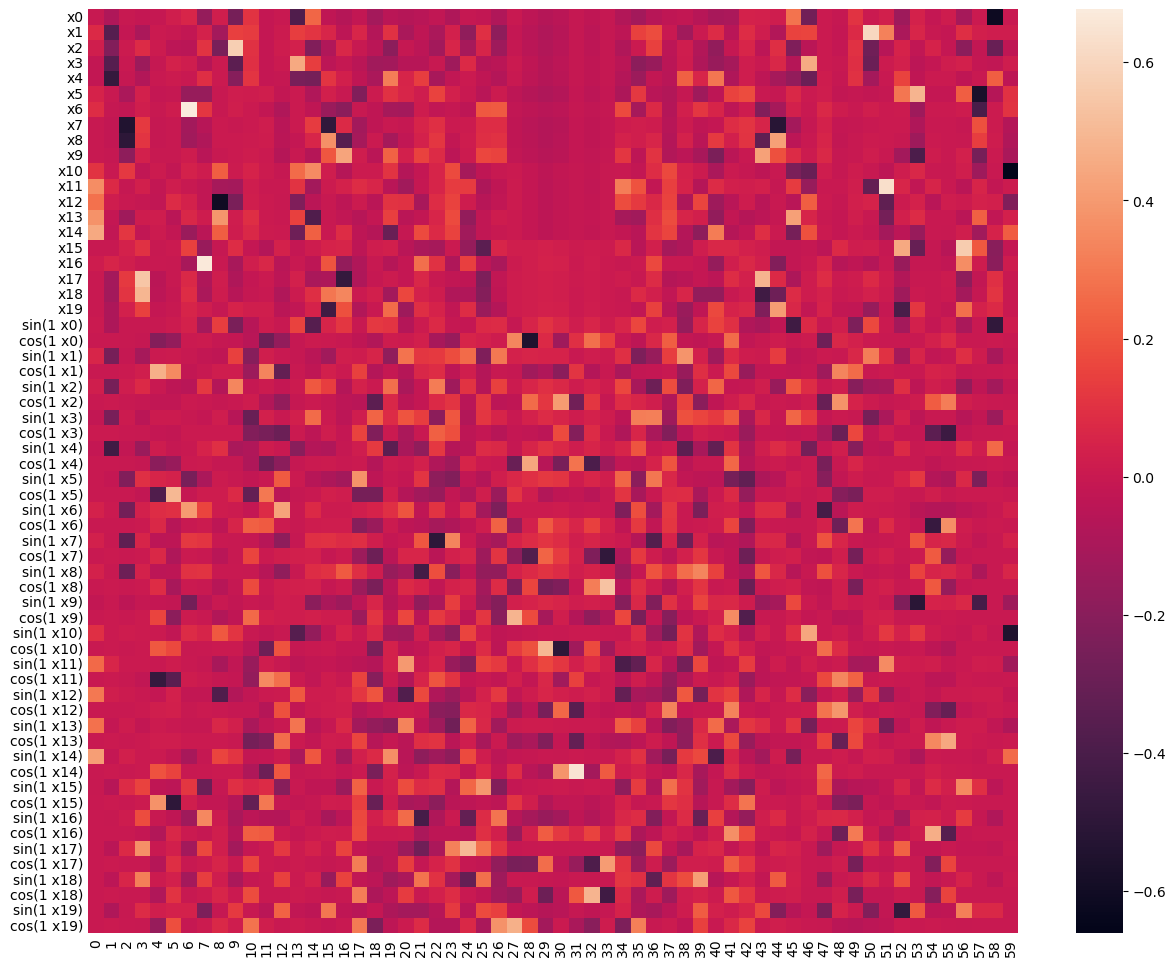

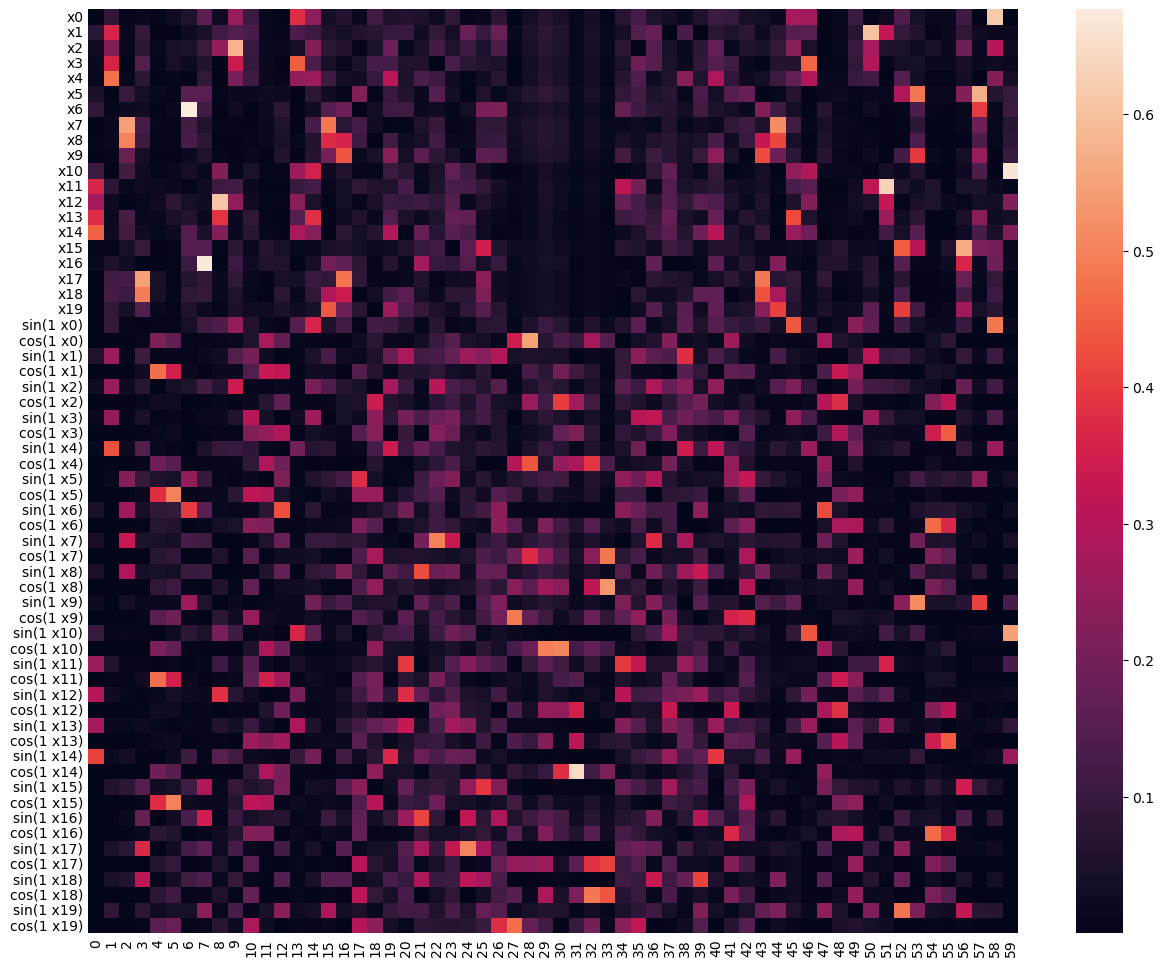

In [28]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U_abs, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show() 

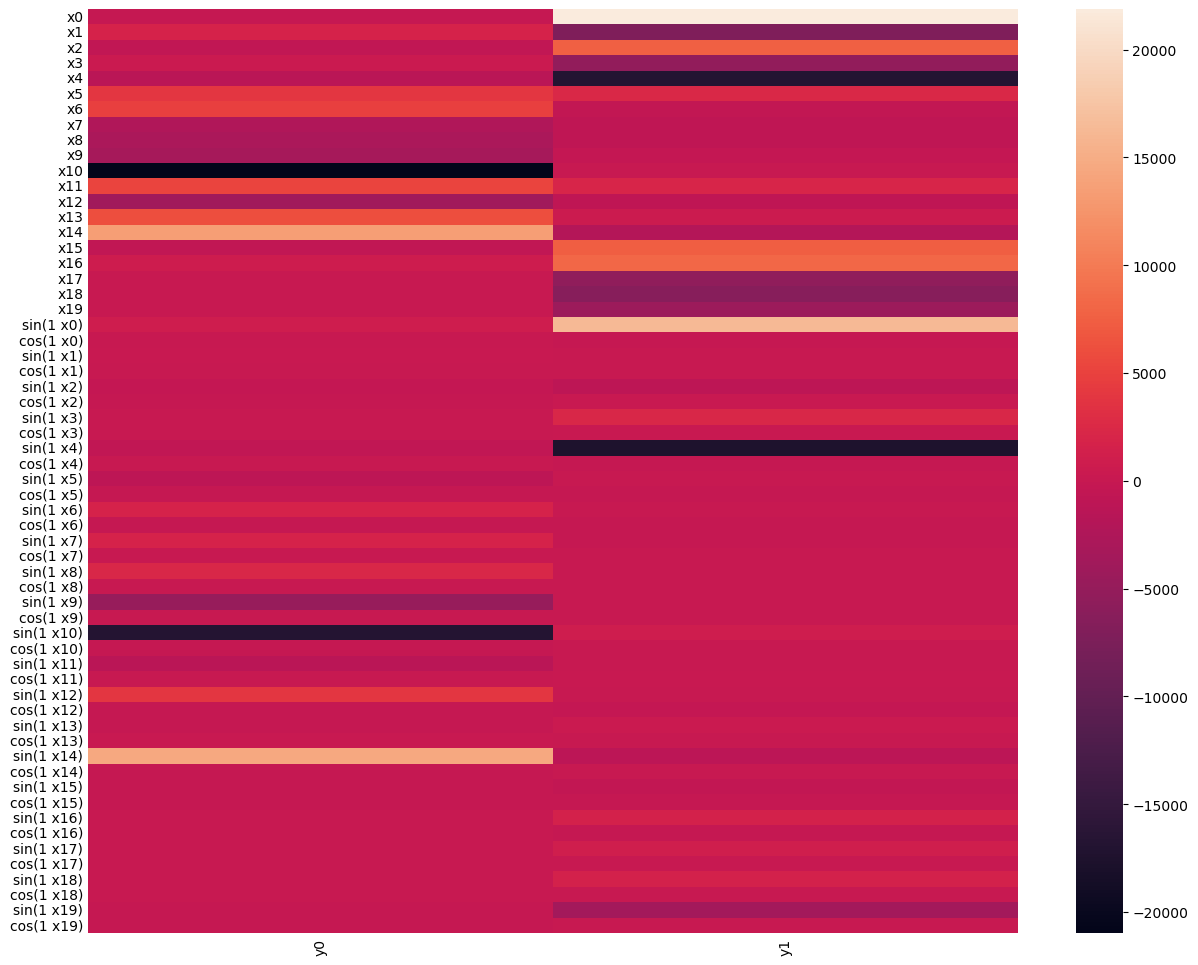

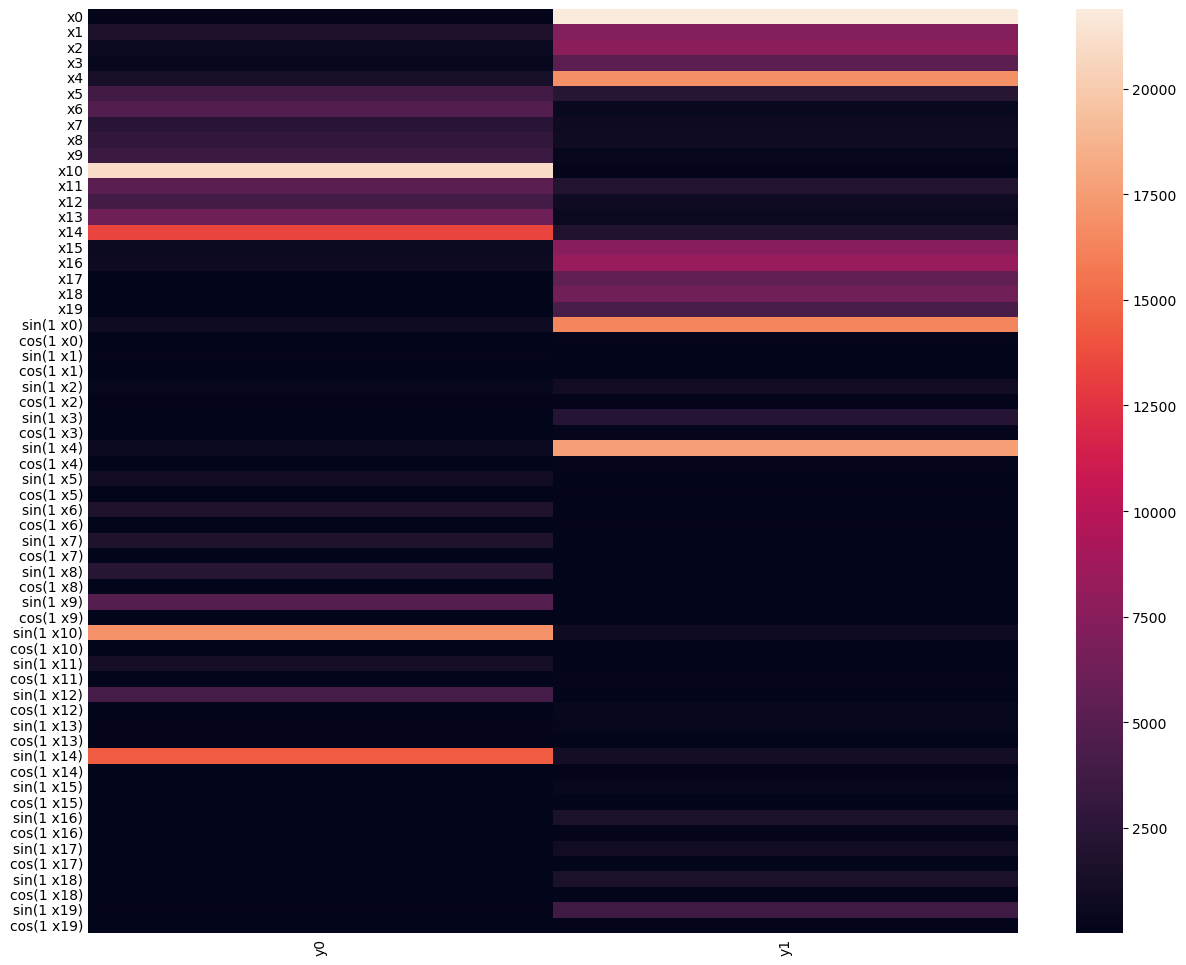

In [29]:
# 粗粒化函数系数
macro_name = [f'y{i}' for i in range(rank)]
coarse_grain_coff = G_inv_sqrt @ U[:,:rank]

plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()

In [30]:
# 输出粗粒化函数表达式
print_equations(coarse_grain_coff, names, macro_name)

y0 = -126.5091 * x0 + 1644.0979 * x1 - 610.2745 * x2 + 371.3558 * x3 - 1331.6817 * x4 + 3829.8726 * x5 + 4675.1649 * x6 - 2389.3624 * x7 - 2847.8270 * x8 - 3375.0216 * x9 - 20984.5504 * x10 + 5175.3561 * x11 - 3888.2978 * x12 + 6116.9397 * x13 + 13408.6900 * x14 - 671.1903 * x15 + 768.4828 * x16 - 48.3497 * x17 + 29.8929 * x18 - 46.2234 * x19 + 789.4598 * sin(1 x0) - 29.8216 * cos(1 x0) + 191.7652 * sin(1 x1) + 90.0429 * cos(1 x1) - 343.7360 * sin(1 x2) - 106.8694 * cos(1 x2) + 47.6418 * sin(1 x3) + 69.2754 * cos(1 x3) - 653.9645 * sin(1 x4) - 7.3467 * cos(1 x4) - 950.5176 * sin(1 x5) - 67.2479 * cos(1 x5) + 1731.6564 * sin(1 x6) - 85.5544 * cos(1 x6) + 1755.3205 * sin(1 x7) + 36.6017 * cos(1 x7) + 2258.4700 * sin(1 x8) + 42.5396 * cos(1 x8) - 4803.6278 * sin(1 x9) + 57.5894 * cos(1 x9) - 16942.7591 * sin(1 x10) - 80.3096 * cos(1 x10) - 1272.7561 * sin(1 x11) + 73.8688 * cos(1 x11) + 3940.4082 * sin(1 x12) - 50.2402 * cos(1 x12) - 104.5994 * sin(1 x13) + 126.9514 * cos(1 x13) + 14406.7

# 描述宏观演化

/var/folders/mw/53dhwskj4zq47dtls4lhht4m0000gn/T/ipykernel_4285/2767867501.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


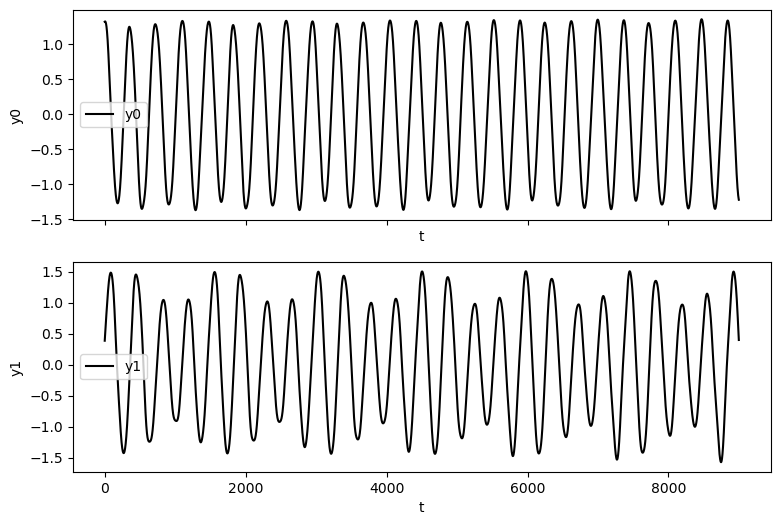

In [31]:
macro_data = x_data_lift @ coarse_grain_coff
macro_dim = macro_data.shape[1]

fig, axs = plt.subplots(macro_dim, 1, sharex=True, figsize=(9, int(3*macro_dim)))
for i in range(macro_dim):
    axs[i].plot(macro_data[0:, i], "k", label=f"y{i}")
    axs[i].legend()
    axs[i].set(xlabel="t", ylabel=f"y{i}")
fig.show()

In [32]:
# 给出宏观动力学方程
A_macro = coarse_grain_coff.T @ A @ coarse_grain_coff
macro_name_k = [i+'[k]' for i in macro_name]
macro_name_next = [i+'[k+1]' for i in macro_name]
print_equations(A_macro, macro_name_k, macro_name_next)

y0[k+1] = 1315145729.1515 * y0[k] - 7216447.5504 * y1[k]
------------------------------
y1[k+1] = 4643968.3698 * y0[k] + 1730573411.5912 * y1[k]
------------------------------


# 频谱分析

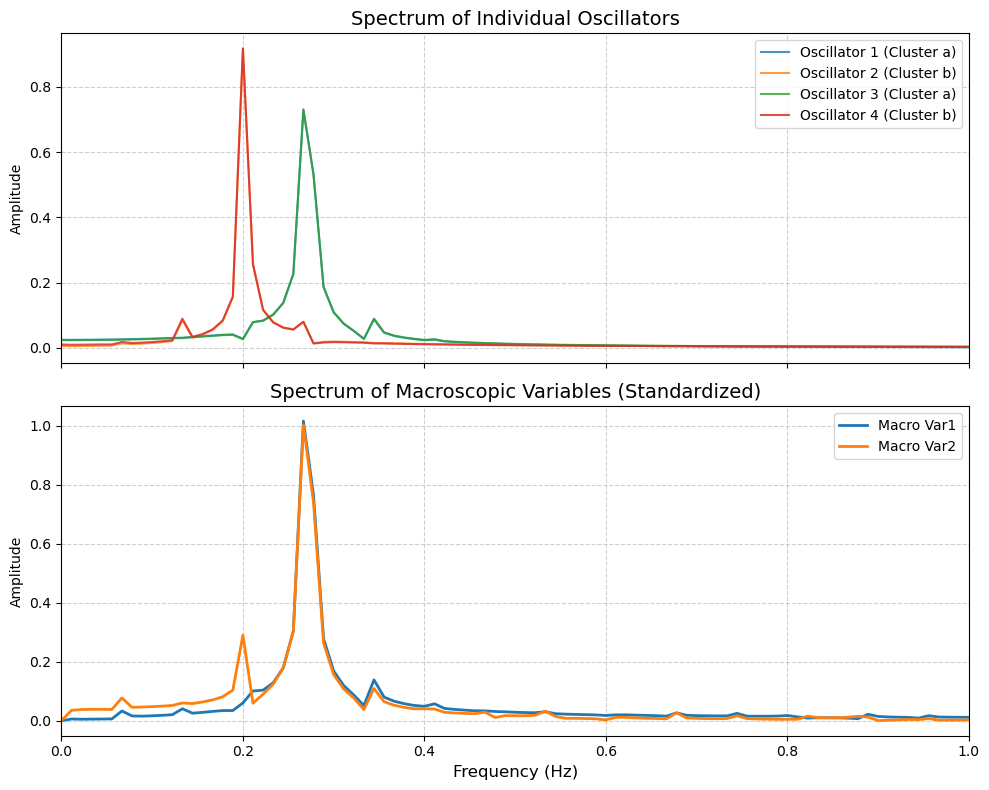

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

n_fft = macro_data.shape[0]
xf = np.fft.fftfreq(n_fft, dt)

micro_signals = [x_data[:, 0], x_data[:, 5], x_data[:, 1], x_data[:, 6]]
micro_labels = [
    'Oscillator 1 (Cluster a)',
    'Oscillator 2 (Cluster b)',
    'Oscillator 3 (Cluster a)',
    'Oscillator 4 (Cluster b)'
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

macro_signals = []
for i in range(macro_dim):
    sig = macro_data[0:, i]
    std = np.std(sig)
    standardized_sig = (sig - np.mean(sig)) / (std + 1e-12)
    macro_signals.append(standardized_sig)
macro_labels = [f'Macro Var{i+1}' for i in range(macro_dim)]

def compute_fft(signal, xf, n_fft):
    yf = fft(signal)
    half_n = n_fft // 2
    return xf[:half_n], np.abs(yf[:half_n]) / n_fft * 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i, sig in enumerate(micro_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax1.plot(freqs, amps, label=micro_labels[i], color=colors[i], alpha=0.8)

ax1.set_title("Spectrum of Individual Oscillators", fontsize=14)
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle='--', alpha=0.6)

for i, sig in enumerate(macro_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax2.plot(freqs, amps, label=macro_labels[i], color=colors[i % len(colors)], linewidth=2)

ax2.set_title("Spectrum of Macroscopic Variables (Standardized)", fontsize=14)
ax2.set_xlabel("Frequency (Hz)", fontsize=12)
ax2.set_ylabel("Amplitude")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()


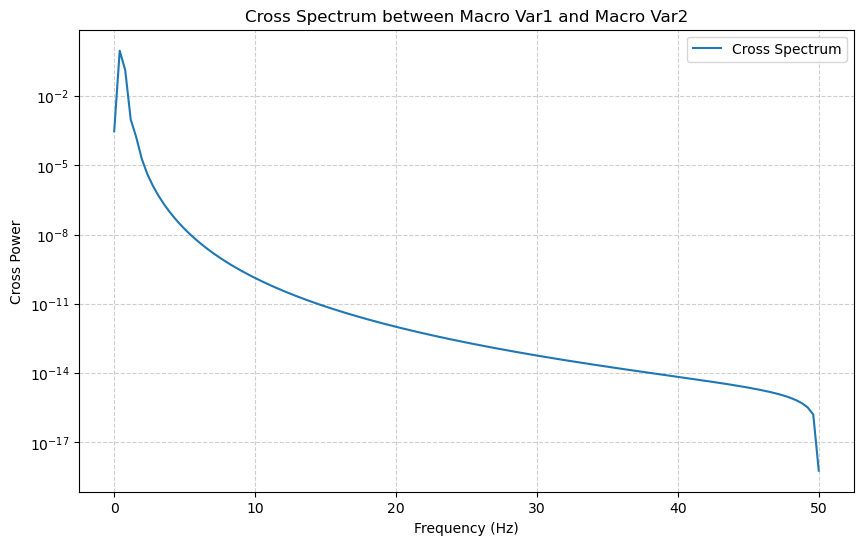

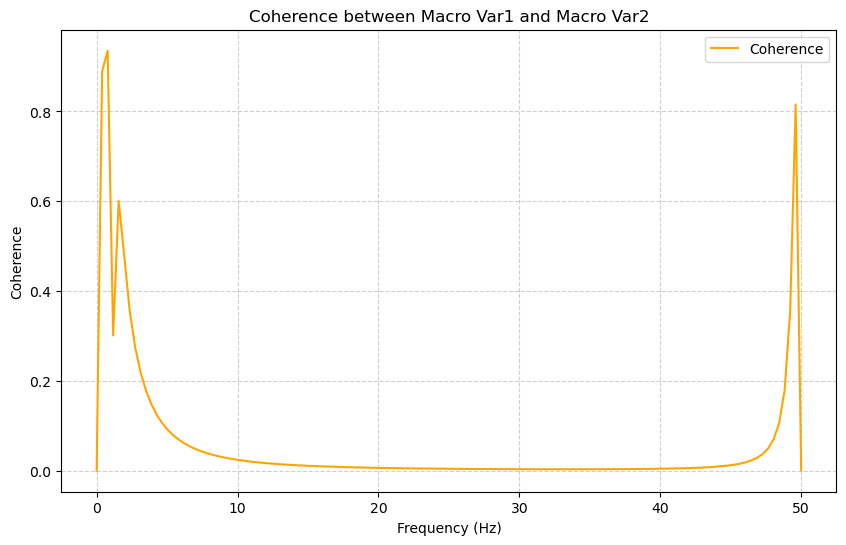

In [34]:
from scipy.signal import coherence, csd
import matplotlib.pyplot as plt

# 计算交叉频谱和相干性
def compute_cross_spectrum_and_coherence(signal1, signal2, fs):
    # 交叉频谱
    f, Pxy = csd(signal1, signal2, fs=fs, nperseg=256)
    # 相干性
    f_coh, Cxy = coherence(signal1, signal2, fs=fs, nperseg=256)
    return f, Pxy, f_coh, Cxy

# 示例：计算宏观变量之间的交叉频谱和相干性
fs = 1 / dt  # 采样频率
macro_var1 = macro_signals[0]
macro_var2 = macro_signals[1]

f, Pxy, f_coh, Cxy = compute_cross_spectrum_and_coherence(macro_var1, macro_var2, fs)

# 可视化交叉频谱
plt.figure(figsize=(10, 6))
plt.semilogy(f, np.abs(Pxy), label='Cross Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Cross Power')
plt.title('Cross Spectrum between Macro Var1 and Macro Var2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 可视化相干性
plt.figure(figsize=(10, 6))
plt.plot(f_coh, Cxy, label='Coherence', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.title('Coherence between Macro Var1 and Macro Var2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()